In [6]:
import torch
import cv2
import numpy as np
import requests
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

In [7]:
def load_image(url):
    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
    image = image.resize((256,256))
    return np.array(image)

In [8]:
def load_mask(url):
    mask = Image.open(requests.get(url, stream=True).raw).convert("L")
    mask = mask.resize((256,256))
    mask = np.array(mask)
    mask = (mask > 127).astype(np.uint8)  # binary mask
    return mask

In [9]:
class URLDataset(torch.utils.data.Dataset):
    def __init__(self, image_urls, mask_urls):
        self.image_urls = image_urls
        self.mask_urls = mask_urls

    def __len__(self):
        return len(self.image_urls)

    def __getitem__(self, idx):
        image = load_image(self.image_urls[idx])
        mask = load_mask(self.mask_urls[idx])

        image = image / 255.0
        image = np.transpose(image,(2,0,1))
        mask = np.expand_dims(mask,0)

        return torch.tensor(image).float(), torch.tensor(mask).float()

In [10]:
image_urls = [
"https://images.pexels.com/photos/614810/pexels-photo-614810.jpeg",
"https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
]

# sample masks (white = subject, black = background)
mask_urls = [
"https://i.imgur.com/8zQZ6Gx.png",
"https://i.imgur.com/2yYayZk.png"
]

In [15]:
dataset = URLDataset(image_urls, mask_urls)
loader = torch.utils.data.DataLoader(dataset, batch_size=2)

In [16]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)

model = model.to(device)

print("Model ready ✅")

Model ready ✅


In [17]:
import requests
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

def load_image(url):
    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
    image = image.resize((256,256))
    return image

In [18]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [19]:
def predict(image_url, model, device):
    model.eval()

    image = load_image(image_url)
    image_np = np.array(image)

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

        # DeepLab case
        if isinstance(output, dict):
            output = output['out']

    pred = torch.argmax(output[0], dim=0).cpu().numpy()

    # person class = 15
    mask = (pred == 15).astype(np.uint8)

    result = image_np.copy()
    result[mask == 0] = 0

    return image_np, mask, result

In [20]:
image_url = "https://images.pexels.com/photos/614810/pexels-photo-614810.jpeg"

orig, mask, result = predict(image_url, model, device)

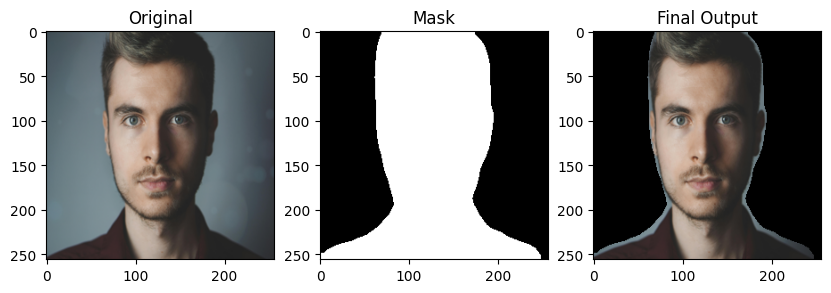

In [21]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(orig)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(result)
plt.title("Final Output")

plt.show()

In [22]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)
model = model.to(device)
model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [23]:
import requests
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

In [24]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [27]:
image_urls = [
    "https://images.pexels.com/photos/458799/pexels-photo-458799.jpeg",   # dog
    "https://images.pexels.com/photos/276517/pexels-photo-276517.jpeg",   # car
    "https://images.pexels.com/photos/358070/pexels-photo-358070.jpeg",   # motorcycle
    "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"  # cat
]

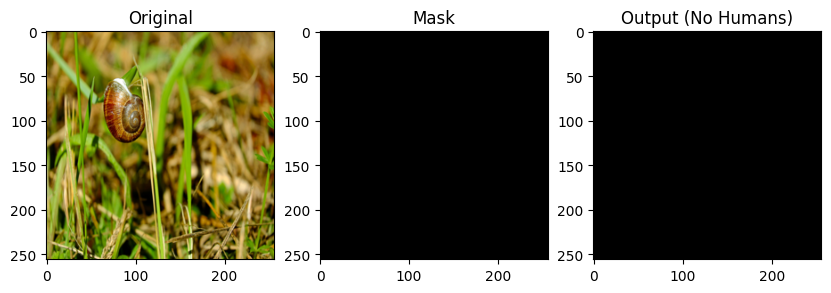

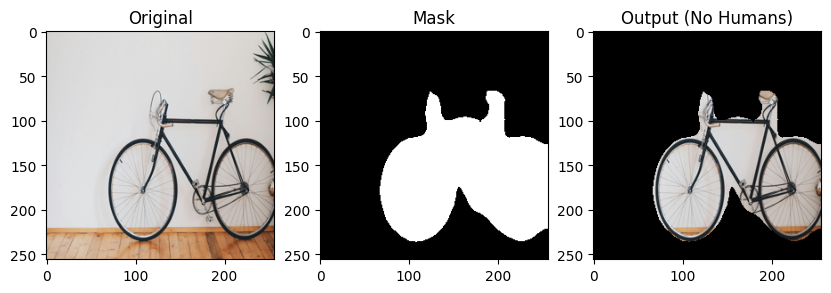

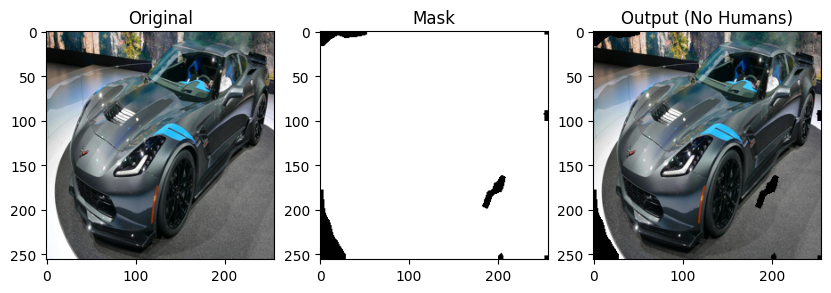

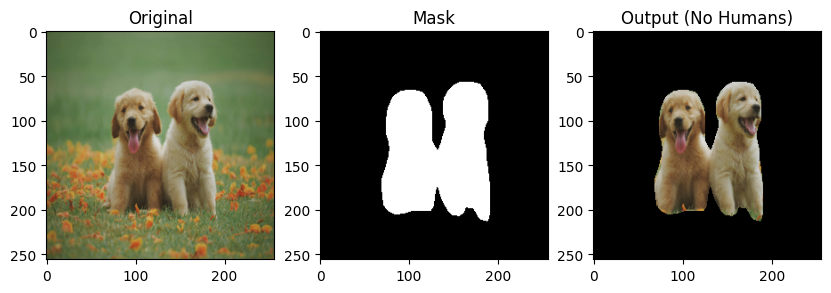

In [28]:
for url in image_urls:

    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
    image_resized = image.resize((256,256))
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)['out'][0]

    pred = torch.argmax(output, dim=0).cpu().numpy()

    # 🔥 Only NON-HUMAN classes
    unique_classes = np.unique(pred)

    if 12 in unique_classes:
        mask = (pred == 12).astype(np.uint8)   # dog
    elif 8 in unique_classes:
        mask = (pred == 8).astype(np.uint8)    # cat
    elif 7 in unique_classes:
        mask = (pred == 7).astype(np.uint8)    # car
    elif 2 in unique_classes:
        mask = (pred == 2).astype(np.uint8)    # bicycle/motorbike
    else:
        mask = (pred > 0).astype(np.uint8)     # fallback

    image_np = np.array(image_resized)

    result = image_np.copy()
    result[mask == 0] = 0

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(image_np)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")

    plt.subplot(1,3,3)
    plt.imshow(result)
    plt.title("Output (No Humans)")

    plt.show()